Principalmente, *Python* mette a disposizione due moduli per la programmazione concorrente:
- **threading**: permette la creazione di software multi-thread
- **multiprocessing**: permette la creazione di software multi-process

Entrambi i moduli mettono a disposizione i meccanismi necessari a supportare l'esecuzione di **codice concorrente**.

### `threading`
Dalla documentazione ufficiale:

> This module constructs higher-level threading interfaces on top of the lower level _thread module.

> The threading module provides a way to run multiple **threads** (smaller units of a process) concurrently within a single process. It allows for the *creation and management* of threads, making it possible to execute tasks in parallel, sharing memory space. Threads are particularly useful when tasks are **I/O bound**, such as file operations or making network requests, where much of the time is spent waiting for external resources.

Il modulo `threading` mette a disposizione un insieme di classi:

In [ ]:
import threading
import inspect

inspect.getmembers(threading, inspect.isclass)

#### La classe `Thread`

La classe `Thread` rappresenta un'attività che esegue in un flusso di controllo separato (thread). In Python esiste un oggetto "main thread" (istanza della classe `_MainThread`) che corrisponde al flusso di controllo associato all'intero programma Python.

> Tutti i thread in Python condividono lo spazio di memoria dle processo padre.

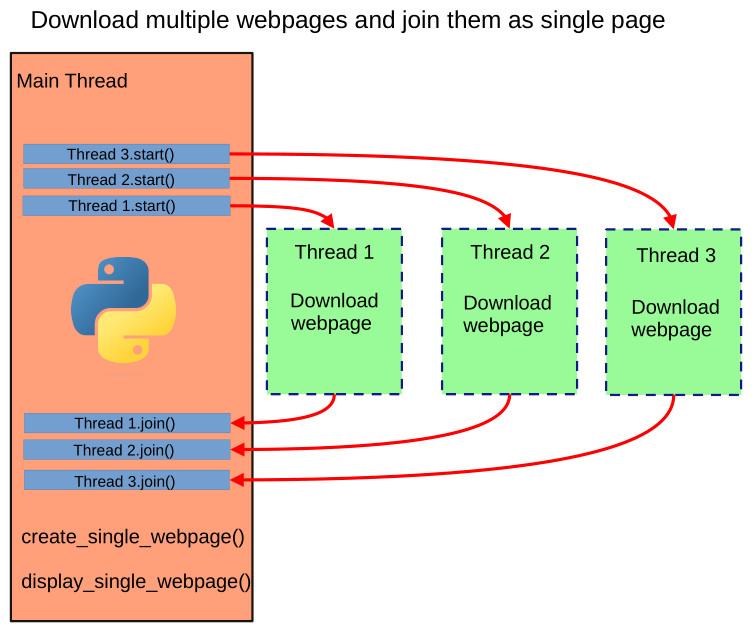

Esistono vari modi di creare thread in Python, ad esempio:
1. istanziare un oggetto `Thread` passando un *callable object* al costruttore della classe
2. creare una classe che estende quella `Thread` e ridefinire il metodo `run()` 

In [ ]:
# [1]

def func():
    print("Thread running")
    
if __name__ == "__main__":
    # creating thread
    t1 = threading.Thread(target=func)
    # starting thread
    t1.start()
    # wait until the thread finishes
    t1.join()

In [ ]:
# [2]

class myThread(threading.Thread):
    def run(self):
        print("Thread running")

if __name__ == "__main__":
    # creating thread
    t1 = myThread()
    # starting thread
    t1.start()
    # wait until the thread finishes
    t1.join()

Dalla documentazione ufficiale:

> `class threading.Thread(group=None, target=None, name=None, args=(), kwargs={}, *, daemon=None, context=None)`
> 
> This constructor should always be called with keyword arguments.
> 
> Arguments are:
> 
> **group** should be None; reserved for future extension when a ThreadGroup class is implemented.
> 
> **target** is the callable object to be invoked by the run() method. Defaults to None, meaning nothing is called.
> 
> **name** is the thread name. By default, a unique name is constructed of the form “Thread-N” where N is a small decimal number, or “Thread-N (target)” where “target” is target.__name__ if the target argument is specified.
> 
> **args** is a list or tuple of arguments for the target invocation. Defaults to ().
> 
> **kwargs** is a dictionary of keyword arguments for the target invocation. Defaults to {}.
> 
> If not None, **daemon** explicitly sets whether the thread is daemonic. If None (the default), the daemonic property is inherited from the current thread.

Alcuni dei metodi offerti dalla classe `Thread` sono:
- `start()`
- `run()`
- `join()`
- `is_alive()`

In [ ]:
help(threading.Thread.start)
help(threading.Thread.run)
help(threading.Thread.join)
help(threading.Thread.is_alive)

Un `thread` è un normalissimo **oggetto** Python: ciò vuol dire che è possibile accedere a qualsiasi attributo dell'oggetto o invocare qualsiasi metodo finché l'oggetto esiste, anche dopo il `join()`, che permette di attendere che il thread finisca l'esecuzione, *ma non lo distrugge*.

In [ ]:
from time import sleep
from threading import Thread
from loguru import logger
import sys

logger.remove()
logger.add(sink=sys.stderr,format="{level} {thread.name} {message}")

class MyThread(Thread):
    def run(self):
        logger.info("Running")
        sleep(3)
        logger.info("is alive {}", self.is_alive())
    
    def method1(self):
        logger.info("method1 invocated")

m = MyThread()
m.start()
m.join()
m.method1() # <-- Chiamo il metodo anche dopo il join
logger.info("is alive {}", m.is_alive()) # <-- Idem qui

Da notare come per `logger.info(f"is alive {m.is_alive()}")` il log sia `INFO MainThread is alive False`, in quanto `{thread.name}` nel formatter logga il thread che sta eseguendo il metodo. Per avere `INFO MainThread Thread-192 is alive False` dovresti usare `logger.info(f"{m.name} is alive {m.is_alive()}")`

##### *daemon* thread vs *non-daemon* thread
Dalla documentazione ufficiale della classe `Thread` c'era questo parametro:

> If not None, **daemon** explicitly sets whether the thread is daemonic. **If None (the default), the daemonic property is inherited from the current thread.**

Cioè si distinguono due tipi di thread:
- *daemon* - i thread di questo tipo veogno interrotti alla terminazione del processo, quindi le loro risorse (come file aperti, transazioni di database etc.) potrebbero non essere rilasciate correttamente
- *non-daemon* - i thread di questo tipo impediscono al programma di terminare, o meglio:

>  *il programma non può terminare se c’è almeno un thread non-daemon ancora vivo*

**Esempi di utilizzo di *non-daemon* thread**:
- **Elaborazione di file**: Si supponga che il programma avvii un thread che scrive dati su un file o esegue un'operazione di backup. Non si vuole che il programma termini prima che l'operazione sia completata, perché ciò potrebbe causare dati
incompleti o corrotti.
- **Richieste di rete**: Un thread normale non può essere usato per gestire attività importanti come l'invio o la ricezione di dati in rete, perché deve poter completare correttamente la comunicazione prima che il programma termini.
- **Elaborazione di dati in background**: Se i calcoli richiedono tempo (ad esempio, l'elaborazione di dati pesanti o la simulazione), è necessario che il thread che li gestisce completi prima che il programma esca, per garantire risultati corretti

**Esempio** (codice in `non_daemon_thread.py`)
```python
from time import sleep
import threading
from threading import Thread
from loguru import logger
import sys
import argparse

logger.remove()
logger.add(sink=sys.stderr,format="{level} {thread.name} {message}")

class MyThread(Thread):
    def run(self):
        logger.info("Running")
        for i in range(10):
            sleep(1)
            logger.info(f"Still running, Main thread is alive: {threading.main_thread().is_alive()}")

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--daemon", action=argparse.BooleanOptionalAction)
    args = parser.parse_args()
    
    m = MyThread(daemon=args.daemon)
    m.start()

    if m.is_alive():
        return # <-- Forzo la terminazione
    
if __name__ == "__main__":

    main()
    logger.info(f"Is alive {threading.main_thread().is_alive()}")
```

In [ ]:
!uv run python -u non_daemon_thread.py --no-daemon

In [ ]:
!uv run python -u non_daemon_thread.py --daemon

##### La classe `local`
Come precedentemente detto:

> Tutti i thread in Python condividono lo spazio di memoria dle processo padre.

Potrebbe tuttavia essere necessario definire variaili specifiche per i casi d'uso specifici, per evitare effetti collaterali indesiderati. Per questo scolo threading offre  la classe `local`:

In [ ]:
import threading
from loguru import logger
import random

logger.remove()
logger.add(sink=sys.stderr,format="{level} {thread.name} {message}")

def show(d):
    try:
        val = d.val
    except AttributeError:
        logger.warning("No value yet")
    else:
        logger.info("value: {}", val)

def f(d):
    show(d)
    d.val=random.randint(1,100)
    show(d)
    logger.info("d id: {}", id(d))

def main():
    d = threading.local()
    logger.info("d id: {}", id(d))
    show(d)
    d.val = 999
    show(d)

    threads = []
    for i in range(2):
        t = threading.Thread(target=f, args=(d,))
        t.start()
        threads.append(t)

    for t in threads:
        t.join()
    
if __name__ == "__main__":
    main()


Come si evince da questo esempio, l'ggetto `d` è lo stesso per tutti i thread (id = `140430736333280`), ma mantiene i valori separati!

#### La classe `Lock`
Dalla documentazione ufficiale:

> A primitive **lock** is a synchronization primitive that is not owned by a particular thread when locked. In Python, *it is currently the lowest level synchronization primitive available, implemented directly by the _thread extension module.*
>
> A primitive lock is in one of two states, *“locked”* or *“unlocked”*. It is created in the unlocked state. It has two basic methods, `acquire()` and `release()`. When the state is unlocked, `acquire()` changes the state to locked and returns immediately. When the state is locked, `acquire()` blocks until a call to `release()` in another thread changes it to unlocked, then the `acquire()` call resets it to locked and returns. **The release() method should only be called in the locked state; it changes the state to unlocked and returns immediately. If an attempt is made to release an unlocked lock, a RuntimeError will be raised.**
>
> When more than one thread is blocked in `acquire()` waiting for the state to turn to unlocked, only one thread proceeds when a release() call resets the state to unlocked; **which one of the waiting threads proceeds is not defined, and may vary across implementations.**

In [ ]:
help(threading.Lock.acquire)
help(threading.Lock.release) # <-- Non prevede un valore di ritorno
help(threading.Lock.locked)

In [ ]:
from threading import Thread, Lock
from loguru import logger

logger.remove()
logger.add(sink=sys.stderr,format="{level} {thread.name} {message}")
counter = 0

def increase(by, lock):
    global counter
    lock.acquire()
    local_counter = counter
    local_counter += by
    counter = local_counter
    logger.info("Counter: {}", counter)    
    lock.release()

def main():
    lock = Lock()
    # create threads
    t1 = Thread(target=increase, args=(10, lock))
    t2 = Thread(target=increase, args=(20, lock))
    # start the threads
    t1.start()
    t2.start()
    # wait for the threads to complete
    t1.join()
    t2.join()
    logger.info("The final counter is {}", counter)

if __name__ == '__main__':
    main()

Invece della coppia `acquire()` e `release()` è possibile usare lo statement `with()`. L'esempio precedente diventa:

In [ ]:
from threading import Thread, Lock
from loguru import logger

logger.remove()
logger.add(sink=sys.stderr,format="{level} {thread.name} {message}")
counter = 0

def increase(by, lock):
    global counter
    with lock: # <-- Niente più acquire() e release()
        local_counter = counter
        local_counter += by
        counter = local_counter
        logger.info("Counter: {}", counter)    

def main():
    lock = Lock()
    # create threads
    t1 = Thread(target=increase, args=(10, lock))
    t2 = Thread(target=increase, args=(20, lock))
    # start the threads
    t1.start()
    t2.start()
    # wait for the threads to complete
    t1.join()
    t2.join()
    logger.info("The final counter is {}", counter)

if __name__ == '__main__':
    main()

#### La classe `RLock`
La classe `RLock` implementa i ***reentrant lock***, ovvero lock che possono essere acquisiti più volte dallo stesso thread. Dalla documentazione ufficiale:

> A reentrant lock is a synchronization primitive that may be acquired multiple times by the same thread. Internally, it uses the concepts of ***“owning thread”*** and ***“recursion level”*** in addition to the locked/unlocked state used by primitive locks. In the locked state, some thread owns the lock; in the unlocked state, no thread owns it.
>
> Threads call a lock’s `acquire()` method to lock it, and its `release()` method to unlock it.

Due principali differenze:
- se la `acquire()` è invocata da un thread che già ha acquisito il lock (owning thread), la chiamata non è bloccante e viene **incrementato il recursion level**
- la `release()` rilascia il lock e **decrementa il recursion level**
- solo quando il *recursion level diventa pari a zero*, il lock passa allo stato unlocked, e potrà essere effettivamente
acquisito da un altro thread

La classe `Condition`
La classe Condition implementa una condition variable: permettono ad uno o più thread di rimanere in attesa (che una determinata condizione si verifichi) fino a quando non saranno notificati da un altro thread (quando la condizione è verificata). Dalla documentazione ufficiale:

> A condition variable is always **associated with some kind of lock**; this can be passed in or one will be created by default. Passing one in is useful when several condition variables must share the same lock. The lock is part of the condition object: you don’t have to track it separately.
>
> A condition variable obeys the context management protocol: using the `with` statement acquires the associated lock for the duration of the enclosed block. The `acquire()` and `release()` methods also call the corresponding methods of the associated lock.
>
> Other methods must be called with the associated lock held. The `wait()` method releases the lock, and then blocks until another thread awakens it by calling `notify()` or `notify_all()`. Once awakened, `wait()` re-acquires the lock and returns. It is also possible to specify a timeout.
>
> The `notify()` method wakes up one of the threads waiting for the condition variable, if any are waiting. The `notify_all()` method wakes up all threads waiting for the condition variable.
>
> **Note**: the `notify()` and `notify_all()` methods **don’t release the lock**; this means that the thread or threads awakened will not return from their `wait()` call immediately, but only when the thread that called `notify()` or `notify_all()` **finally relinquishes ownership of the lock**.

In [ ]:
help(threading.Condition.__init__) # <-- Se lock == None, un RLock sarà creato automaticamente
help(threading.Condition.wait) # <-- Restituisce False nel caso di timeout scaduto, True in tutti gli altri casi
help(threading.Condition.wait_for)
help(threading.Condition.notify)
help(threading.Condition.notify_all)

Un esempio di utilizzo potrebbe essere il seguente, con il tipico problema del produttore - consumatore (pseudocodice):

```python
cv_lock = threading.Lock()
cv = Condition(lock=cv_lock)
. . .
# Consume one item
with cv:
    while not an_item_is_available(queue):
        cv.wait()

    """
    Oppure, invece di usare il while + wait(), puoi usare il wait_for():
    cv.wait_for(an_item_is_available(queue))
    """
    get_an_available_item(queue)

# Produce one item
with cv:
    make_an_item_available(queue)
    cv.notify()
```

#### La classe `Semaphore`
Dalla documentazione ufficiale:
> This is one of the oldest synchronization primitives in the history of computer science, invented by the early Dutch computer scientist Edsger W. Dijkstra (he used the names P() and V() instead of acquire() and release()).
>
> A semaphore manages an internal counter which is decremented by each acquire() call and incremented by each release() call. The counter can never go below zero; when acquire() finds that it is zero, it blocks, waiting until some other thread calls release().

In [ ]:
help(threading.Semaphore.__init__) # <-- Il semaforo viene inizializzato a valore 1
help(threading.Semaphore.acquire)
help(threading.Semaphore.release)

#### La classe `Event`
Dalla documentazione ufficiale:

> This is one of the simplest mechanisms for communication between threads: one thread signals an event and other threads wait for it.
>
> An event object manages an internal flag that can be set to true with the set() method and reset to false with the clear() method. The wait() method blocks until the flag is true.

In [ ]:
help(threading.Event.__init__)
help(threading.Event.set)
help(threading.Event.clear)
help(threading.Event.is_set)
help(threading.Event.wait)

In [ ]:
from threading import Event, Thread
import time
from loguru import logger

logger.remove()
logger.add(sink=sys.stderr, format = "{level} {thread.name} {message}")

def task(event, timeout):
    logger.info("Started thread but waiting for event...")
    # make the thread wait for event with timeout set
    event_set = event.wait(timeout)
    if event_set:
        logger.info("Event received, releasing thread...")
    else:
        logger.info("Time out, moving ahead without event...")

if __name__ == '__main__':
    # initializing the event object
    e = Event()
    # starting the thread
    thread = Thread(name='Event-Thread', target=task, args=(e,4))
    thread.start()
    # sleeping the main thread for 3 seconds
    time.sleep(3)
    # generating the event
    e.set()
    logger.info("Event is set.")
    # wait for the thread to complete
    thread.join()